<a href="https://colab.research.google.com/github/nlan082/bai_tap_AI/blob/main/2_4_Maygiat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 15.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [4]:
load=ctrl.Antecedent(np.arange(0, 2.1, 0.1),'load')
dirt=ctrl.Antecedent(np.arange(0, 2.1, 0.1),'dirt')
fabric=ctrl.Antecedent(np.arange(0, 2.1, 0.1),'fabric')
#
time=ctrl.Consequent(np.arange(0, 2.1, 0.1),'time')
water=ctrl.Consequent(np.arange(0, 2.1, 0.1),'water')

In [12]:
#
load['s']=fuzz.trimf(load.universe, [0, 0, 1])
load['m']=fuzz.trimf(load.universe, [0, 1, 2])
load['l']=fuzz.trimf(load.universe, [1, 2, 2])
dirt['l']=fuzz.trimf(dirt.universe, [0, 0, 1])
dirt['m']=fuzz.trimf(dirt.universe, [0, 1, 2])
dirt['h']=fuzz.trimf(dirt.universe, [1, 2, 2])
fabric['s']=fuzz.trimf(fabric.universe, [0, 0, 1])
fabric['m']=fuzz.trimf(fabric.universe, [0, 1, 2])
fabric['l']=fuzz.trimf(fabric.universe, [1, 2, 2])

#
time['s']=fuzz.trimf(time.universe, [0, 0, 1])
time['m']=fuzz.trimf(time.universe, [0, 1, 2])
time['l']=fuzz.trimf(time.universe, [1, 2, 2])
water['l']=fuzz.trimf(water.universe, [0, 0, 1])
water['m']=fuzz.trimf(water.universe, [0, 1, 2])
water['h']=fuzz.trimf(water.universe, [1, 2, 2])



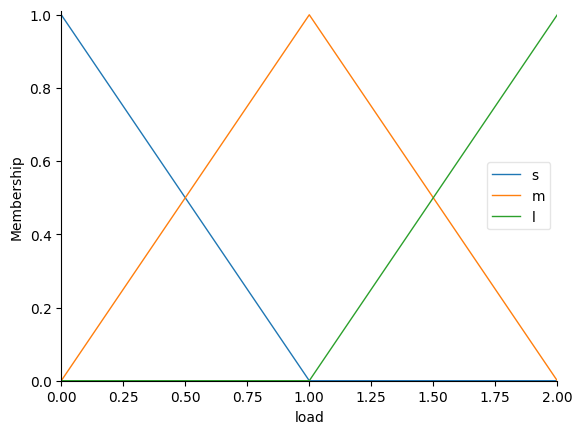

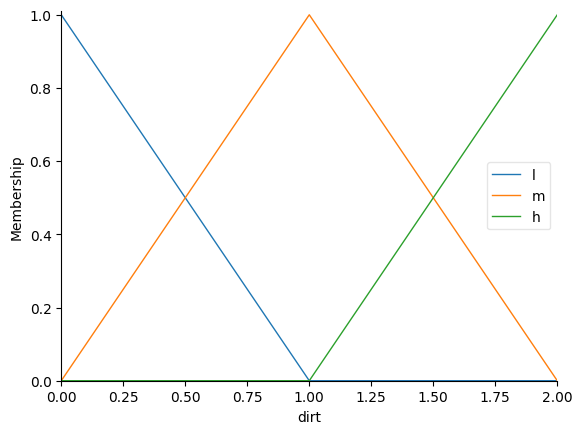

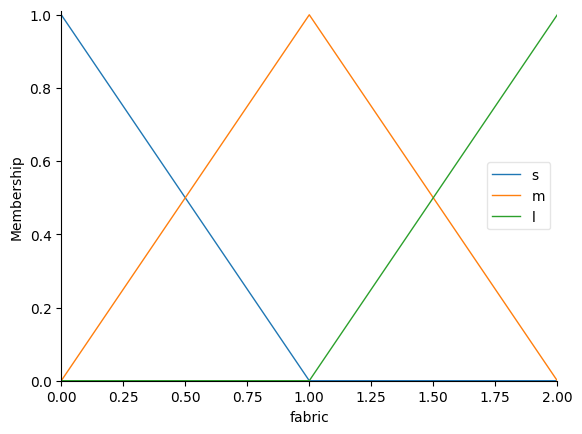

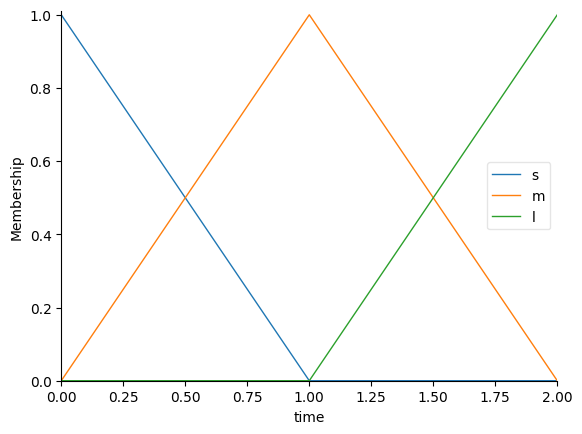

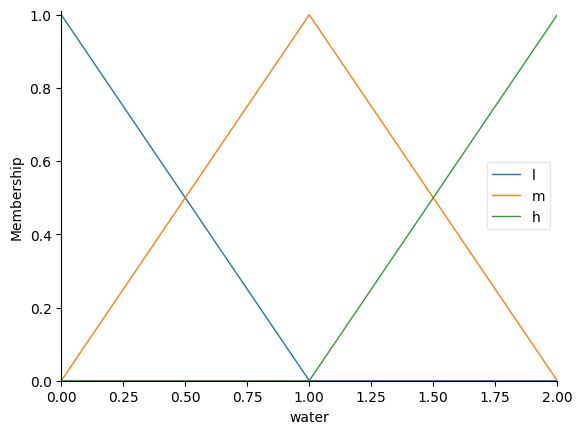

In [13]:
load.view()
dirt.view()
fabric.view()
time.view()
water.view()


In [28]:
rule1=ctrl.Rule(load['s']&dirt['l'],(time['s'],water['l']))
rule2=ctrl.Rule(load['s']&dirt['m'],(time['m'],water['m']))
rule3=ctrl.Rule(load['s']&dirt['h'],(time['l'],water['m']))
rule4=ctrl.Rule(load['m']&dirt['l'],(time['m'],water['m']))
rule5=ctrl.Rule(load['m']&dirt['m'],(time['l'],water['h']))
rule6=ctrl.Rule(load['m']&dirt['h'],(time['l'],water['m']))
rule7=ctrl.Rule(load['l']&dirt['m'],(time['m'],water['h']))
rule8=ctrl.Rule(load['l']&dirt['l'],(time['l'],water['h']))
rule9=ctrl.Rule(load['l']&dirt['m'],(time['l'],water['h']))
rule10=ctrl.Rule(load['l']&dirt['h'],(time['l'],water['h']))
#
rule11=ctrl.Rule(fabric['s'], (time['s'], water['l']))

#
rule14=ctrl.Rule(load['l']&dirt['h']& fabric['l'], (time['l'], water['h']))
rule15=ctrl.Rule(load['l']&dirt['h']& fabric['m'], (time['l'], water['h']))
rule16=ctrl.Rule(load['m']&dirt['m']& fabric['m'], (time['m'], water['m']))



1.119047619047619
1.119047619047619


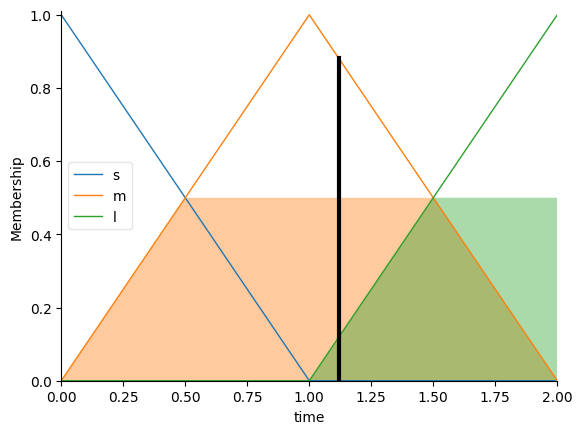

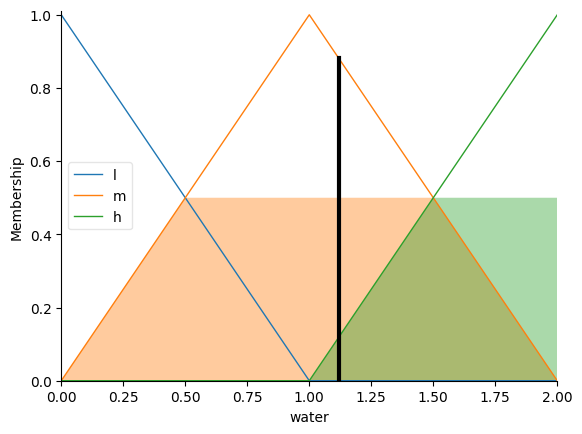

In [34]:
time_water=ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9,rule10,rule11,rule14,rule15,rule16])
time_water_sim=ctrl.ControlSystemSimulation(time_water)
time_water_sim.input['load']=0.5
time_water_sim.input['dirt']=1
time_water_sim.input['fabric']=1
time_water_sim.compute()
print(time_water_sim.output['time'])
print(time_water_sim.output['water'])
time.view(sim=time_water_sim)
water.view(sim=time_water_sim)